# 03 — Model Training

## Architecture
```
Linear(n_features → 64) → ReLU → Dropout(0.1)
Linear(64 → 32) → ReLU
Linear(32 → 1)
```

## Training protocol
- Loss: Huber (δ=1.0) — robust to outlier bars
- Optimizer: Adam (lr=1e-3)
- Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
- Early stopping: patience=10 on val MAE
- Temporal split: 65% train / 15% val / 20% test
- Scaler fitted on train only (no data leakage)

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from slippage.features import FEATURE_NAMES_TRAINING
from slippage.pipeline import build_full_dataset
from slippage.training import train
from slippage.viz import plot_training_history, FIGURES_DIR

In [2]:
data, proxy_all, split = build_full_dataset()
print(f'Train: {len(split.X_train):,}  Val: {len(split.X_val):,}  Test: {len(split.X_test):,}')

[data] SPY: 3425 bars (2024-06-05 → 2026-05-22)
[data] QQQ: 3407 bars (2024-06-05 → 2026-05-22)
[data] IWM: 3427 bars (2024-06-05 → 2026-05-22)
[data] AAPL: 3419 bars (2024-06-05 → 2026-05-22)
[data] MSFT: 3419 bars (2024-06-05 → 2026-05-22)
[data] GOOGL: 3424 bars (2024-06-05 → 2026-05-22)
[data] JPM: 3427 bars (2024-06-05 → 2026-05-22)
[data] GS: 3427 bars (2024-06-05 → 2026-05-22)
[data] XOM: 3426 bars (2024-06-05 → 2026-05-22)
[data] SLB: 3427 bars (2024-06-05 → 2026-05-22)
[data] PRCT: 3427 bars (2024-06-05 → 2026-05-22)


Train: 97,331  Val: 22,461  Test: 29,948


In [3]:
model, history = train(
    split,
    n_features=len(FEATURE_NAMES_TRAINING),
    epochs=100,
    batch_size=256,
    lr=1e-3,
    patience=10,
    seed=42,
    verbose=True,
)
print(f'\nBest epoch: {history["best_epoch"]}  |  Best val MAE: {history["best_val_mae"]:.4f} bps')

Adaptive Huber delta = 21.86 bps (median|y_train|)


Epoch 001  train_loss=146.6579  val_mae=6.3833


Epoch 010  train_loss=31.2841  val_mae=4.4094


Epoch 020  train_loss=29.3677  val_mae=4.3302


Epoch 030  train_loss=28.9413  val_mae=4.3237


Epoch 040  train_loss=28.2773  val_mae=4.2592


Epoch 050  train_loss=28.0560  val_mae=4.2862


Early stopping at epoch 52 (best epoch 42)
Model saved to /Users/francesconatale/Documents/projects/slippage-predictor/artifacts/checkpoints/model_checkpoint.pt

Best epoch: 42  |  Best val MAE: 4.2500 bps


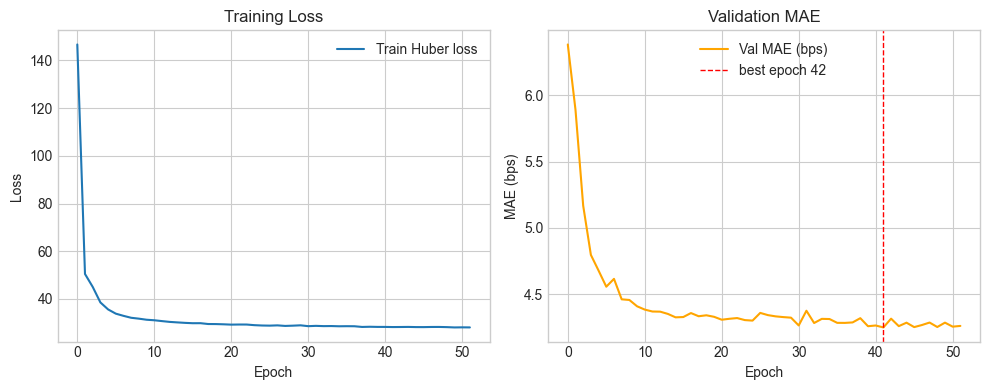

In [4]:
fig = plot_training_history(history, save_as='training_history.png')
plt.show()

In [5]:
# Save split metadata for notebook 04
import pickle
results_dir = pathlib.Path.cwd().parent / 'results'
results_dir.mkdir(exist_ok=True)
with open(results_dir / 'split_metadata.pkl', 'wb') as f:
    pickle.dump({'n_train': len(split.X_train), 'n_val': len(split.X_val), 'n_test': len(split.X_test)}, f)
print('Checkpoint and metadata saved.')

Checkpoint and metadata saved.
